## Lab 3.1 – Skin Cancer classification: MobileNetV2 (PyTorch)

This notebook is a PyTorch version of the Teachable Machine skin cancer classification evaluation.

Dataset consisting of 7 classes: Melanoma(MEL), Melanocytic nevi(NV), Basal cell carcinoma(BCC), Actinic keratoses(AKIEC), Benign keratosis lesions(BKL), Dermatofibroma(DF), and Vascular lesions(VASC)

This example code will consist of:

0. **Setup**
1. **Load Data**
2. **Load Model**
3. **Inference & Evaluate**

## 0) Setup
The code below install and import all required libraries and defines utility functions that will be used in the rest of this notebook.

In [1]:
# # Download library
# !pip install torch torchvision torchinfo

In [2]:
# Import library
import os
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
from PIL import Image, ImageOps

import matplotlib.image as mpimg
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

import warnings

warnings.simplefilter(action="ignore", category=FutureWarning)
warnings.simplefilter(action="ignore", category=pd.errors.SettingWithCopyWarning)

# Set device
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda:0


## 1) Load Data

In this step, the dataset is downloaded from GitHub. The directory structure is different from that used in Teachable Machine. Please refer to the following paths:
/content/images/ and /content/GroundTruth.csv

In [3]:
# # Download Prepared dataset from github
# !wget https://github.com/pvateekul/digitalhealth-ai2025/raw/main/dataset/Ham10000_torch.zip
# !unzip -q -o 'Ham10000_torch.zip'

In [4]:
# Load & Split dataset

dataset_path = "/workspaces/Datasets/Digihealth/Ham10000_torch"

df = pd.read_csv(f"{dataset_path}/GroundTruth.csv")
df["image"] = df["image"].apply(lambda x: f"{dataset_path}/images/" + x + ".jpg")
df = df.drop(columns=["Unnamed: 0"])
df.head()

,image,MEL,NV,BCC,AKIEC,BKL,DF,VASC
0,/workspaces/Datasets/Digihealth/Ham10000_torch...,1,0,0,0,0,0,0
1,/workspaces/Datasets/Digihealth/Ham10000_torch...,0,1,0,0,0,0,0
2,/workspaces/Datasets/Digihealth/Ham10000_torch...,0,0,1,0,0,0,0
3,/workspaces/Datasets/Digihealth/Ham10000_torch...,0,0,0,1,0,0,0
4,/workspaces/Datasets/Digihealth/Ham10000_torch...,0,0,0,0,1,0,0


In [5]:
lesion_type_dict = {
    "MEL": "Melanoma",
    "NV": "Melanocytic nevi",
    "BCC": "Basal cell carcinoma",
    "AKIEC": "Actinic keratoses",
    "BKL": "Benign keratosis lesions",
    "DF": "Dermatofibroma",
    "VASC": "Vascular lesions",
}

labels = list(df.columns[1:])
label_list = []
full_label_list = []
for i in range(len(df)):
    row = list(df.iloc[i])[1:]
    index = np.argmax(row)
    label = labels[index]
    label_list.append(label)

    full_label = lesion_type_dict[labels[index]]
    full_label_list.append(full_label)
df["label"] = label_list
df["full_label"] = full_label_list

train_df, val_df, test_df = df[:210], df[210:280], df[280:350]

print("Data Test:", len(test_df))
train_df.reset_index(drop=True, inplace=True)
val_df.reset_index(drop=True, inplace=True)
test_df.reset_index(drop=True, inplace=True)

test_df.head()

Data Test: 70


,image,MEL,NV,BCC,AKIEC,BKL,DF,VASC,label,full_label
0,/workspaces/Datasets/Digihealth/Ham10000_torch...,1,0,0,0,0,0,0,MEL,Melanoma
1,/workspaces/Datasets/Digihealth/Ham10000_torch...,0,1,0,0,0,0,0,NV,Melanocytic nevi
2,/workspaces/Datasets/Digihealth/Ham10000_torch...,0,0,1,0,0,0,0,BCC,Basal cell carcinoma
3,/workspaces/Datasets/Digihealth/Ham10000_torch...,0,0,0,1,0,0,0,AKIEC,Actinic keratoses
4,/workspaces/Datasets/Digihealth/Ham10000_torch...,0,0,0,0,1,0,0,BKL,Benign keratosis lesions


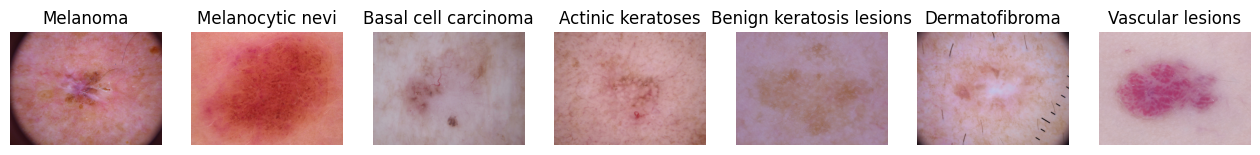

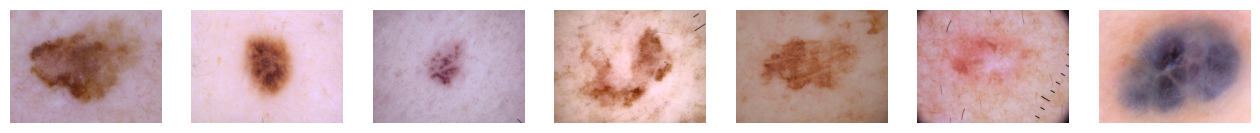

In [6]:
# Example image
for i in range(2):
    plt.figure(figsize=(16, 14))
    for j in range(7):
        plt.subplot(1, 7, j + 1)
        plt.imshow(mpimg.imread(test_df.image[j + (i * 7)]))
        plt.axis("off")
        if not i:
            plt.title(test_df.full_label[j])

## 2) Load Model

Load a pre-trained MobileNetV2 model from PyTorch (similar to Teachable Machine's MobileNet).

Note: Teachable Machine uses a custom-trained MobileNet. For demonstration, we use a pre-trained MobileNetV2 from torchvision. To use your actual Teachable Machine model, you would need to convert it to ONNX format or export the weights.

In [7]:
# Define class names (same order as Teachable Machine)
class_names = ["AKIEC", "BCC", "BKL", "DF", "MEL", "NV", "VASC"]
num_classes = len(class_names)
print(f"Classes: {class_names}")

Classes: ['AKIEC', 'BCC', 'BKL', 'DF', 'MEL', 'NV', 'VASC']


In [8]:
# Load pre-trained MobileNetV2 from torchvision
# This is equivalent to the model architecture used in Teachable Machine
model = models.mobilenet_v2(weights="IMAGENET1K_V1")

# Replace the classifier for 7 classes
model.classifier[1] = nn.Linear(model.classifier[1].in_features, num_classes)

# Move model to device
model = model.to(device)

# Set model to evaluation mode
model.eval()

print(f"Model loaded: MobileNetV2")
print(f"Number of classes: {num_classes}")

Downloading: "https://download.pytorch.org/models/mobilenet_v2-b0353104.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-b0353104.pth


100.0%


Model loaded: MobileNetV2
Number of classes: 7


## 3) Inference & Evaluate

In [9]:
# Define image preprocessing (same as Teachable Machine: 224x224, normalize to [-1, 1])
preprocess = transforms.Compose(
    [
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),  # Maps to [-1, 1]
    ]
)

In [10]:
# Inference
output_list = []
confidence_score_list = []

with torch.no_grad():
    for i in range(len(test_df)):
        # Load and preprocess image
        image = Image.open(test_df.image[i]).convert("RGB")
        image_tensor = preprocess(image).unsqueeze(0).to(device)

        # Predict
        outputs = model(image_tensor)
        probabilities = torch.nn.functional.softmax(outputs, dim=1)

        # Get prediction
        confidence, index = torch.max(probabilities, 1)
        class_name = class_names[index.item()]
        confidence_score = confidence.item()

        output_list.append(class_name)
        confidence_score_list.append(confidence_score)

test_df.loc[:, "output"] = output_list
test_df.loc[:, "confidence"] = confidence_score_list

print("Inference complete!")

Inference complete!


In [15]:
test_df.shape

(70, 12)

In [11]:
test_df.head()

,image,MEL,NV,BCC,AKIEC,BKL,DF,VASC,label,full_label,output,confidence
0,/workspaces/Datasets/Digihealth/Ham10000_torch...,1,0,0,0,0,0,0,MEL,Melanoma,BCC,0.237821
1,/workspaces/Datasets/Digihealth/Ham10000_torch...,0,1,0,0,0,0,0,NV,Melanocytic nevi,AKIEC,0.181402
2,/workspaces/Datasets/Digihealth/Ham10000_torch...,0,0,1,0,0,0,0,BCC,Basal cell carcinoma,DF,0.201017
3,/workspaces/Datasets/Digihealth/Ham10000_torch...,0,0,0,1,0,0,0,AKIEC,Actinic keratoses,AKIEC,0.196026
4,/workspaces/Datasets/Digihealth/Ham10000_torch...,0,0,0,0,1,0,0,BKL,Benign keratosis lesions,VASC,0.161034


In [ ]:
# Evaluate
# Classification Report
report = classification_report(test_df.label, test_df.output, digits=4)
M = confusion_matrix(test_df.label, test_df.output)
print(report)
disp = ConfusionMatrixDisplay(confusion_matrix=M, display_labels=class_names)

              precision    recall  f1-score   support

       AKIEC     0.2857    0.4000    0.3333        10
         BCC     0.0000    0.0000    0.0000        10
         BKL     1.0000    0.1000    0.1818        10
          DF     0.2069    0.6000    0.3077        10
         MEL     0.0000    0.0000    0.0000        10
          NV     0.0000    0.0000    0.0000        10
        VASC     0.2500    0.1000    0.1429        10

    accuracy                         0.1714        70
   macro avg     0.2489    0.1714    0.1380        70
weighted avg     0.2489    0.1714    0.1380        70



/opt/conda/envs/digihealth/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/conda/envs/digihealth/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/conda/envs/digihealth/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result

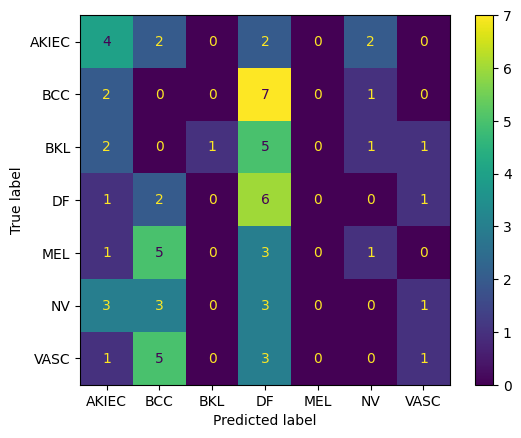

In [13]:
disp.plot()
plt.show()

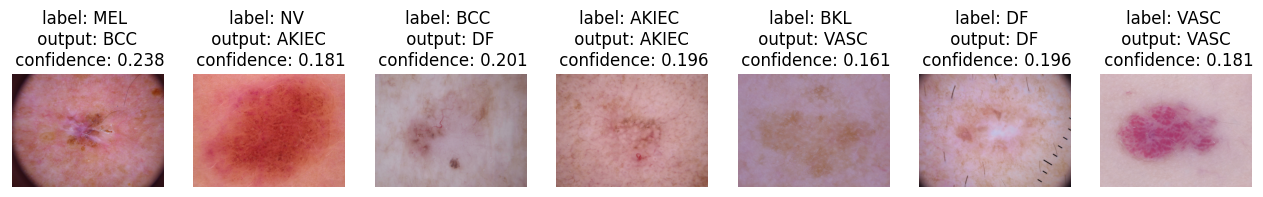

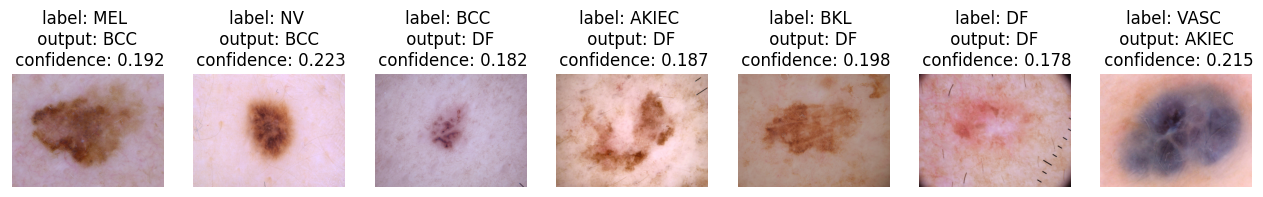

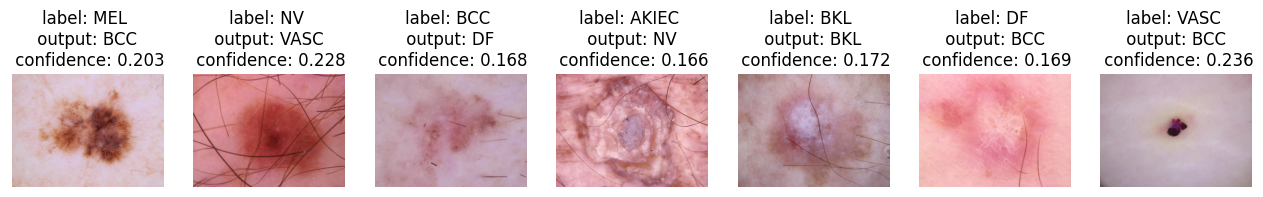

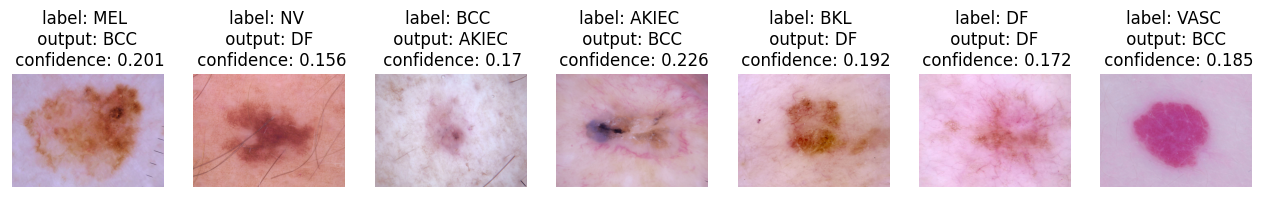

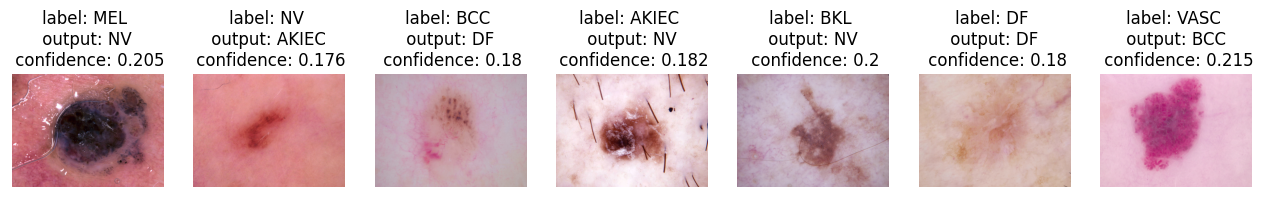

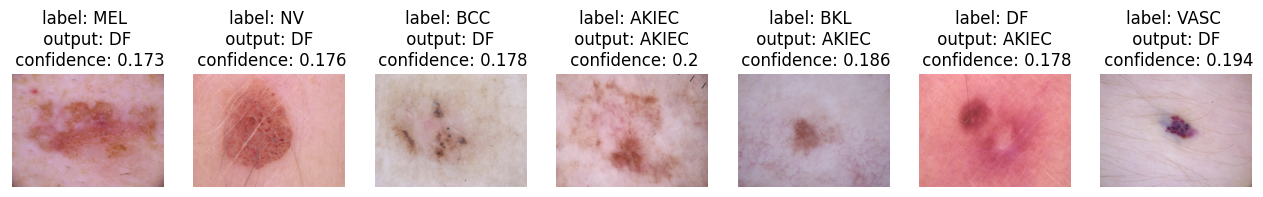

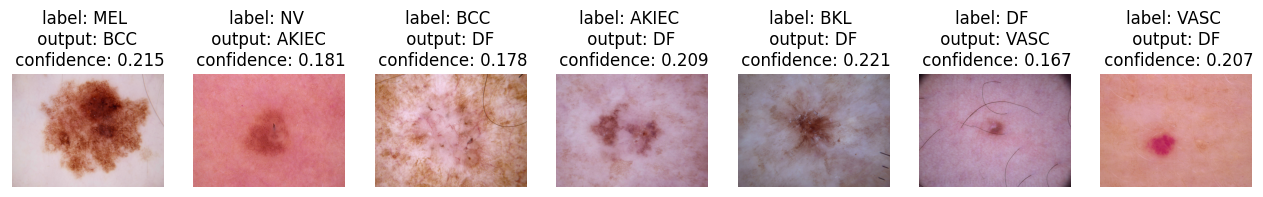

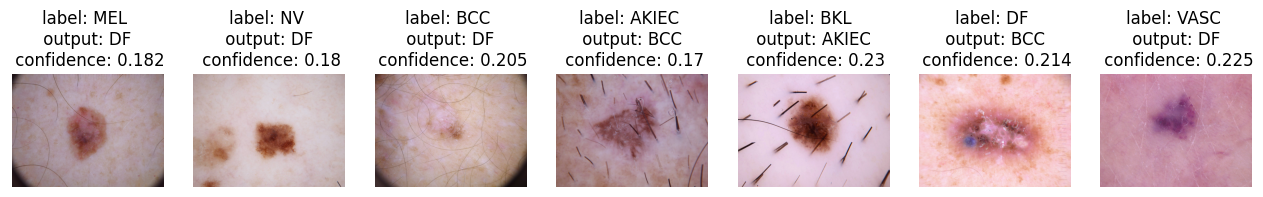

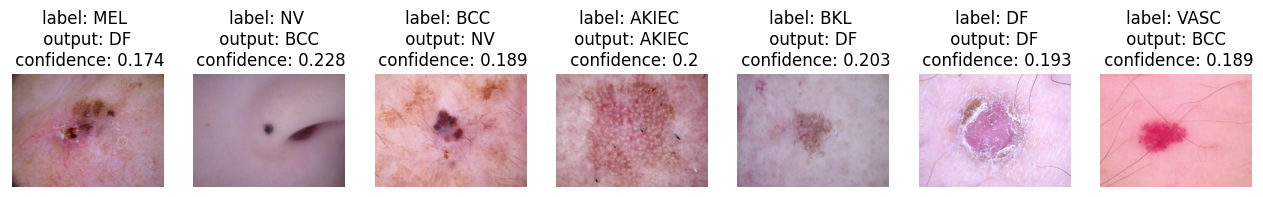

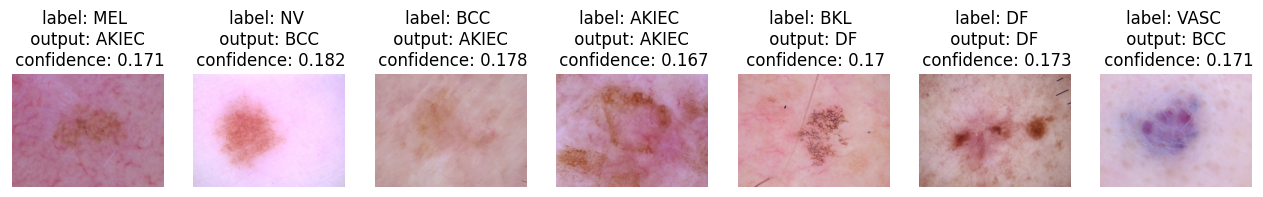

In [14]:
# Example image with predictions
for i in range(10):
    plt.figure(figsize=(16, 14))
    for j in range(7):
        plt.subplot(1, 7, j+1)
        plt.imshow(mpimg.imread(test_df.image[j+(i*7)]))
        plt.axis("off")
        plt.title(f"label: {test_df.label[j+(i*7)]} \n output: {test_df.output[j+(i*7)]} \n confidence: {round(float(test_df.confidence[j+(i*7)]), 3)}")

---

**Note:** This notebook uses a pre-trained MobileNetV2 from torchvision (ImageNet weights). For the actual Teachable Machine model performance, you would need to:
1. Export your Teachable Machine model in ONNX format
2. Load it using `torch.onnx.load()`
3. Or convert the Keras `.h5` model to PyTorch weights

The results shown here are from ImageNet-pretrained MobileNetV2, not a model trained on skin cancer data.